# Setup

In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import torch
import random
from utils.utils import *
from data.simulate_walk_the_book import *
from utils.datastuff import TrainCfg
from utils.train import train_val
from utils.test import generate_test_loader, generate_test_predictions
from data.simulate_walk_the_book import simulate_walk_the_book
import warnings


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Fix randomness for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore", category=UserWarning)

device: cpu


In [2]:

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# are we consuming asks or bids?
side = "ask" # if positions are positive, we consume asks, if negative we consume bids.

In [4]:
import sys, os

# Paths and volume_to_fill
# root_path = DATA_PATH
root_path = "../data"
root = Path(root_path) if Path(root_path).exists() else Path.cwd()

import sys
if str(root / "src") not in sys.path:
    sys.path.append(str(root / "src"))

data_assets = [folder_name for folder_name in os.listdir(root) if "USDT" in folder_name]
data_asset = data_assets[0]

symbol_dir = root / data_asset
X_path = symbol_dir / "X_train.parquet"
Y_path = symbol_dir / "y_train.parquet"
X_test_path = symbol_dir / "X_test.parquet"
vol_path = symbol_dir / "vol_to_fill.txt"

volume_to_fill = None
if vol_path.exists():
    import re
    with open(vol_path) as f:
        m = re.search(r"([\d.]+)", f.read())
    if m:
        volume_to_fill = float(m.group(1))
print("data asset:", data_asset)
print("volume_to_fill:", volume_to_fill)

data asset: BTCUSDT
volume_to_fill: 4.0


In [5]:
volumes_to_fill = {}

for asset in data_assets:
    vol_path = root / asset / "vol_to_fill.txt"
    if vol_path.exists():
        with open(vol_path) as f:
            m = re.search(r"([\d.]+)", f.read())
        if m:            
            volumes_to_fill[asset] = float(m.group(1)) 

import matplotlib.pyplot as plt

def plot_volumes_to_fill():
    # Sort dictionary by values
    sorted_items = sorted(volumes_to_fill.items(), key=lambda x: x[1])

    # Unzip keys and values
    labels, values = zip(*sorted_items)

    # Create bar plot
    plt.figure()
    plt.bar(labels, values)

    # Optional labels
    plt.xlabel("Items")
    plt.ylabel("Values")
    plt.title("Volumes to Fill by Asset")

    plt.show()

In [6]:
# DeepLOB only take LOB features as input
LOB_COLS = []
for i in range(1, 6):
    LOB_COLS.append(f"ask_price_{i}")
    LOB_COLS.append(f"ask_vol_{i}")
    LOB_COLS.append(f"bid_price_{i}")
    LOB_COLS.append(f"bid_vol_{i}")

FEATURE_COLS = LOB_COLS + ["target"]

# Verification print
print(f"CNN Input Width: 4 (Columns: Price/Vol/Price/Vol)")
print(f"CNN Input Height: 5 (Rows: Levels 1 through 5)")
print(f"Total Features: {len(FEATURE_COLS)} (20 LOB + mid_price)")

CNN Input Width: 4 (Columns: Price/Vol/Price/Vol)
CNN Input Height: 5 (Rows: Levels 1 through 5)
Total Features: 21 (20 LOB + mid_price)


In [7]:
ASK_PRICE_COLS = ['ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_price_4', 'ask_price_5']
ASK_VOL_COLS = ['ask_vol_1', 'ask_vol_2', 'ask_vol_3', 'ask_vol_4', 'ask_vol_5']
BID_PRICE_COLS = ['bid_price_1', 'bid_price_2', 'bid_price_3', 'bid_price_4', 'bid_price_5']
BID_VOL_COLS = ['bid_vol_1', 'bid_vol_2', 'bid_vol_3', 'bid_vol_4', 'bid_vol_5']

# Uniform + optimal K as needed

Here you can see the our current best approach for each data asset.

| Asset    | Optimal K | bps_optimal_K |
|----------|----------|--------------|
| BTCUSDT  | 14       | 1.323212     |
| ETHUSDT  | 26       | 2.712073     |
| LTCUSDT  | 16       | 4.819771     |
| SOLUSDT  | 17       | 5.343504     |
| ADAUSDT  | 7        | 4.628115     |
| DOGEUSDT | 20       | 4.976437     |
| XRPUSDT  | 20       | 3.567023     |


In [8]:
df_k = pd.DataFrame({
    "Asset": [
        "BTCUSDT", "ETHUSDT", "LTCUSDT",
        "SOLUSDT", "ADAUSDT", "DOGEUSDT", "XRPUSDT"
    ],
    "Optimal_K": [
        14, 26, 16,
        17, 7, 20, 20
    ],
    "bps_optimal_K": [
        1.323212, 2.712073, 4.819771,
        5.343504, 4.628115, 4.976437, 3.567023
    ]
})

df_k

,Asset,Optimal_K,bps_optimal_K
0,BTCUSDT,14,1.323212
1,ETHUSDT,26,2.712073
2,LTCUSDT,16,4.819771
3,SOLUSDT,17,5.343504
4,ADAUSDT,7,4.628115
5,DOGEUSDT,20,4.976437
6,XRPUSDT,20,3.567023


In [9]:
optimal_k = df_k[df_k["Asset"] == data_asset]["Optimal_K"].iloc[0]

> **New approach**
>
> * If volatility is high → use uniform weights
> * If volatility is low → use a trend strategy

> Apply this independently for each anonymized ID.


In [10]:
print("cwd:", Path.cwd())
print("exists:", Path(X_path).exists())
print("absolute:", Path(X_path).resolve())

cwd: /Users/joez/Desktop/ESG_DS/WS 25-26/projects/Practical/Ultramarin
exists: True
absolute: /Users/joez/Desktop/ESG_DS/WS 25-26/projects/Practical/data/BTCUSDT/X_train.parquet


In [11]:
X_df = pd.read_parquet(X_path)

In [12]:
# predictive strategies
# if volativty high -> predict uniform
# if clear trend -> predict trend (according to midprice)

volatility_window = 60 # the last __ seconds of the train data hour

# impute prices
X_df = X_df.sort_values(["anonymized_id", "time_in_hour"])
X_df["ask_price_1"] = X_df.groupby("anonymized_id")["ask_price_1"].ffill().bfill()
X_df["bid_price_1"] = X_df.groupby("anonymized_id")["bid_price_1"].ffill().bfill()

X_df["midprice"] = (X_df["ask_price_1"] + X_df["bid_price_1"]) / 2

# volatility measure
X_df["midvolatility"] = X_df.groupby("anonymized_id")["midprice"].transform(lambda x: np.log(x).diff()).fillna(0)

X_df["midvolatilitystd"] = X_df.groupby("anonymized_id")["midvolatility"].transform(lambda x: x.rolling(volatility_window).std()) 

def vol_regime(x):
    low = x.quantile(0.2)
    high = x.quantile(0.8) # TODO: this seems odd... why are we setting it in relation to the hour itself. there should be some kind of universal threshold. maybe this can be a learned threshold.
    return pd.cut(
        x,
        bins=[-np.inf, low, high, np.inf],
        labels=["low", "normal", "high"]
    )

X_df["vol_regime"] = X_df.groupby("anonymized_id")["midvolatilitystd"].transform(vol_regime)

# initialize
X_df["strat"] = None

# get last row per group
last_idx = X_df.groupby("anonymized_id").tail(1).index

# assign based on existing regime
X_df.loc[last_idx, "strat"] = X_df.loc[last_idx, "vol_regime"].map({
    "high": "uniform",
    "low": "trend",
    "normal": "trend"  
})


In [13]:
X_df[["anonymized_id", "time_in_hour", "midprice", "midvolatility", "midvolatilitystd", "vol_regime", "strat"]]

,anonymized_id,time_in_hour,midprice,midvolatility,midvolatilitystd,vol_regime,strat
1522209,10076153343292355,0 days 00:00:00,110096.718860,0.000000,NaN,NaN,None
1522210,10076153343292355,0 days 00:00:01,110108.428800,0.000106,NaN,NaN,None
1522211,10076153343292355,0 days 00:00:02,110108.987420,0.000005,NaN,NaN,None
1522212,10076153343292355,0 days 00:00:03,110108.049360,-0.000009,NaN,NaN,None
1522213,10076153343292355,0 days 00:00:04,110104.687100,-0.000031,NaN,NaN,None
...,...,...,...,...,...,...,...
1242549,18444992991527050644,0 days 00:58:55,78757.546800,-0.000061,0.000071,normal,None
1242550,18444992991527050644,0 days 00:58:56,78757.633560,0.000001,0.000071,normal,None
1242551,18444992991527050644,0 days 00:58:57,78756.932250,-0.000009,0.000068,normal,None
1242552,18444992991527050644,0 days 00:58:58,78760.746075,0.000048,0.000064,normal,None


In [14]:
last_time = X_df["time_in_hour"].iloc[-1]

future_times = pd.Series(
    [last_time + pd.Timedelta(seconds=i) for i in range(1, 61)],
    name="time_in_hour"
)

ids = pd.Series(X_df["anonymized_id"].unique(), name="anonymized_id")

positions_uniform_vs_k = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
    .sort_values(["anonymized_id", "time_in_hour"])
    .reset_index(drop=True)
)

positions_uniform_vs_k["position"] = 0.0

for anon_id in ids:

    strat_series = (
        X_df[X_df["anonymized_id"] == anon_id]["strat"]
        .dropna()
    )

    if strat_series.empty:
        print(f"no strategy found for {anon_id}")
        continue

    strat = strat_series.iloc[0]

    if strat == "uniform":
        weights = np.ones(60) / 60

    elif strat == "trend":
        weights = np.array([0] * (60 - optimal_k) + [1] * optimal_k) / optimal_k

    else:
        print(f"invalid strategy for {anon_id}!!!")
        continue

    # TODO: remove this
    # weights = np.array([0] * (60 - optimal_k) + [1] * optimal_k) / optimal_k

    # assign to correct rows
    mask = positions_uniform_vs_k["anonymized_id"] == anon_id
    positions_uniform_vs_k.loc[mask, "position"] = weights * volume_to_fill

# --- sanity check ---
positions_uniform_vs_k.head()

,anonymized_id,time_in_hour,position
0,10076153343292355,0 days 00:59:00,0.0
1,10076153343292355,0 days 00:59:01,0.0
2,10076153343292355,0 days 00:59:02,0.0
3,10076153343292355,0 days 00:59:03,0.0
4,10076153343292355,0 days 00:59:04,0.0


In [15]:
y_df = pd.read_parquet(Y_path)

full_grid = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
)

y_df = full_grid.merge(
    y_df,
    on=["anonymized_id", "time_in_hour"],
    how="left"
)

# price imputation
price_cols = ASK_PRICE_COLS + BID_PRICE_COLS + ["close"]
X_df[price_cols] = X_df.groupby("anonymized_id")[price_cols].transform(lambda x: x.ffill().bfill())
y_df[price_cols] = y_df.groupby("anonymized_id")[price_cols].transform(lambda x: x.ffill().bfill())

# volume imputation
volume_cols = BID_VOL_COLS + ASK_VOL_COLS + ["volume"]
X_df[volume_cols] = X_df[volume_cols].fillna(0)
y_df[volume_cols] = y_df[volume_cols].fillna(0)


bps_uniform_vs_k = []

for anon_id in ids:
    df_inst = y_df[y_df["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    if len(df_inst) != 60:
        print(len(df_inst))
        print(f"{anon_id} has missing time_in_hour!")
        continue
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]

    id_positions = positions_uniform_vs_k[positions_uniform_vs_k["anonymized_id"] == anon_id].sort_values("time_in_hour")["position"].to_numpy()
    
    # Simulate
    model_vol, model_avg_price = simulate_walk_the_book(
        id_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        bps_uniform_vs_k.append(impl_error * vol_penalty)

bps_uniform_vs_k = np.array(bps_uniform_vs_k)

print(f"\n{'='*50}")
print(f"MODEL IMPLEMENTATION ERROR uniform vs k")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(bps_uniform_vs_k)}")
print(f"Mean:   {bps_uniform_vs_k.mean():.4f} bps")
print(f"Median: {np.median(bps_uniform_vs_k):.4f} bps")
print(f"Std:    {bps_uniform_vs_k.std():.4f} bps")
print(f"Min:    {bps_uniform_vs_k.min():.4f} bps")
print(f"Max:    {bps_uniform_vs_k.max():.4f} bps")


MODEL IMPLEMENTATION ERROR uniform vs k
Instruments evaluated: 705
Mean:   1.2917 bps
Median: 1.1468 bps
Std:    1.0543 bps
Min:    0.0000 bps
Max:    10.5569 bps


> **These are the results of the above strategy**

| Asset    | bps_optimal_K | uniform vs k | volatility seconds | high quantile (uniform above)
|----------|----------|----------|----------|----------|
| XRPUSDT  | **3.567023** | 3.6255 | 60 | 0.8 |
| XRPUSDT  | **3.567023** | 3.6255 | 120 | 0.8 |
| BTCUSDT  | 1.323212 | **1.2186** | 120 | 0.8 |
| BTCUSDT  | 1.323212 | **1.2977** | 30 | 0.8 |
| BTCUSDT  | **1.323212** | 1.4518 | 30 | **0.2** |
| ETHUSDT | 2.712073 | **2.6677** | 120 | 0.8 |
| ADAUSDT | **4.628115** | 5.6869 | 120 | 0.8 |
| SOLUSDT | 5.343504 | **5.2892** | 120 | 0.8 |
| DOGEUSDT | **4.976437** | 5.0007 | 120 | 0.8 |
| LTCUSDT | **4.819771** | 5.3027 | 120 | 0.8 |
| LTCUSDT | **4.819771** | 5.3458 | 30 | 0.8 |

send above results to Maaz...


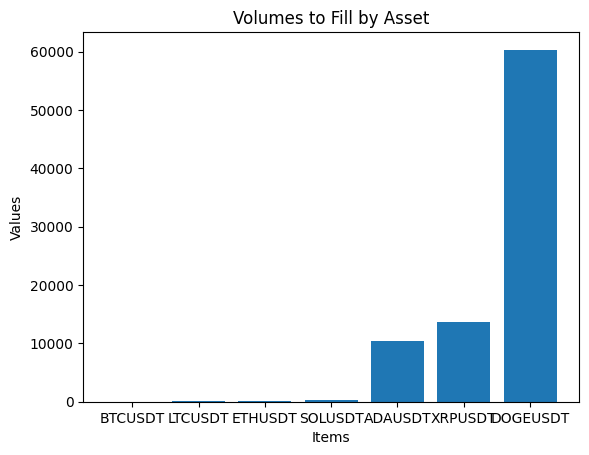

In [16]:
# do doge, ltc, ada and xrp have higher volumes to fill? turns out they do with the exception of LTC
# TODO: ltc is an outlier. maybe it is generally more volatile?
plot_volumes_to_fill()

# uniform + linear, weighted by volatility

we should also think about this a bit more thoroughly. maybe we can try different weighting (quadratic, linear, etc).
additionally, we should take the trend into consideration maybe always

potentially, we could always use a quadratic trend, but increase the quadratic part by how high volatility is. maybe we need a measure for how strong the trend is. if the trend weight is higher, we use more quadratic. if the trend is low, then we use more uniform. we also need to differentiate between volatility and trend. perhaps we can normalize the weights by the trend and then do the volatility measure. that makes the most sense. so we have an overall trend weighting (quadratic) and then volatility normalized by trend as the uniform weighting. 

linear is probably safer. use trend + volatility as signal to noise ratio


TLDR:
- 2 weights: trend + volatility
- normalize the mid price by making the trend flat (trend will be average line -> -trend will make average line flat)
- use trend weight for linear
- use volatility weight for uniform

In [17]:
# the first step is to normalize each anonymized id within itself to make the volatility weights  comparable.

def vol_weight(x):
    last_x = x.iloc[-1]
    return (x <= last_x).mean()

X_df["vol_weight"] = X_df.groupby("anonymized_id")["midvolatilitystd"].transform(vol_weight) # this is the weight for uniform

In [18]:
positions_vol_weights = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
    .sort_values(["anonymized_id", "time_in_hour"])
    .reset_index(drop=True)
)

positions_vol_weights["position"] = 0.0
uniform_weights = []

for anon_id in ids:

    uniform_weight = X_df[X_df["anonymized_id"] == anon_id]["vol_weight"].iloc[0]
    uniform_weights.append(uniform_weight)

    weights_uniform = np.ones(60) / 60
    weights_linear = np.linspace(0, 1, 60) / np.linspace(0, 1, 60).sum()

    weights = weights_linear * (1 - uniform_weight) + weights_uniform * uniform_weight

    if not np.isclose(weights.sum(), 1):
        print(f"{anon_id} doesn't have weights that sum to 1.")

    # assign to correct rows
    mask = positions_vol_weights["anonymized_id"] == anon_id
    positions_vol_weights.loc[mask, "position"] = weights * volume_to_fill

# --- sanity check ---
positions_vol_weights.head()

,anonymized_id,time_in_hour,position
0,10076153343292355,0 days 00:59:00,0.005443
1,10076153343292355,0 days 00:59:01,0.007518
2,10076153343292355,0 days 00:59:02,0.009593
3,10076153343292355,0 days 00:59:03,0.011669
4,10076153343292355,0 days 00:59:04,0.013744


In [19]:
bps_vol_weights = []

for anon_id in ids:
    df_inst = y_df[y_df["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]

    id_positions = positions_vol_weights[positions_vol_weights["anonymized_id"] == anon_id].sort_values("time_in_hour")["position"].to_numpy()
    
    # Simulate
    model_vol, model_avg_price = simulate_walk_the_book(
        id_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        bps_vol_weights.append(impl_error * vol_penalty)

bps_vol_weights = np.array(bps_vol_weights)

print(f"\n{'='*50}")
print(f"MODEL IMPLEMENTATION ERROR volatility weights")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(bps_vol_weights)}")
print(data_asset)

print(f"optimal_k: {df_k[df_k['Asset'] == data_asset]['bps_optimal_K'].iloc[0]} bps")

print(f"Mean:   {bps_vol_weights.mean():.4f} bps")
print(f"Median: {np.median(bps_vol_weights):.4f} bps")
print(f"Std:    {bps_vol_weights.std():.4f} bps")
print(f"Min:    {bps_vol_weights.min():.4f} bps")
print(f"Max:    {bps_vol_weights.max():.4f} bps")


MODEL IMPLEMENTATION ERROR volatility weights
Instruments evaluated: 705
BTCUSDT
optimal_k: 1.323212 bps
Mean:   1.3992 bps
Median: 1.0993 bps
Std:    1.2766 bps
Min:    0.0000 bps
Max:    9.7668 bps


> **These are the results of the above second strategy if we do it the correct way lol (uniform weights for uniform weights)**

> (use this to evaluate approach)

| Asset    | bps_optimal_K | uniform + linear | volatility seconds |
|----------|----------|----------|----------|
| LTCUSDT | **4.819771** | 5.4580 | 120 |
| LTCUSDT | **4.819771** | 5.4540 | 60 |
| LTCUSDT | **4.819771** | 5.4800 | 30 |
| BTCUSDT | **1.323212** | 1.4011 | 30 |
| DOGEUSDT | **4.976437** | 5.1435 | 60 |
| SOLUSDT | **5.343504** | 5.4812 | 60 |
| ADAUSDT | **4.628115** | 5.8602 | 60 |
| ETHUSDT | **2.712073** | 2.7615 | 60 |


> **These are the results of the above second strategy**

| Asset    | bps_optimal_K | uniform + linear | volatility seconds |
|----------|----------|----------|----------|
| LTCUSDT | **4.819771** | 5.4887 | 120 |
| LTCUSDT | **4.819771** | 5.4872 | 60 |
| LTCUSDT | **4.819771** | 5.4725 | 30 |
| BTCUSDT | **1.323212** | 1.3987 | 30 |



In [20]:
np.mean(uniform_weights)

np.float64(0.4537660713843428)

In [21]:
# ok this didn't work.... need to try something else

# uniform + optimal K, weighted by volatility

In [22]:
# same as above, just replacing linear with optimal K

positions_vol_weights_K = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
    .sort_values(["anonymized_id", "time_in_hour"])
    .reset_index(drop=True)
)

positions_vol_weights_K["position"] = 0.0

uniform_weights = []

for anon_id in ids:

    uniform_weight = X_df[X_df["anonymized_id"] == anon_id]["vol_weight"].iloc[0]
    uniform_weights.append(uniform_weight)

    weights_uniform = np.ones(60) / 60
    weights_K = np.array([0] * (60 - optimal_k) + [1] * optimal_k) / optimal_k

    weights = weights_K * (1 - uniform_weight) + weights_uniform * uniform_weight

    if not np.isclose(weights.sum(), 1):
        print(f"{anon_id} doesn't have weights that sum to 1.")

    # assign to correct rows
    mask = positions_vol_weights_K["anonymized_id"] == anon_id
    positions_vol_weights_K.loc[mask, "position"] = weights * volume_to_fill

# --- sanity check ---
positions_vol_weights_K.head()

,anonymized_id,time_in_hour,position
0,10076153343292355,0 days 00:59:00,0.005443
1,10076153343292355,0 days 00:59:01,0.005443
2,10076153343292355,0 days 00:59:02,0.005443
3,10076153343292355,0 days 00:59:03,0.005443
4,10076153343292355,0 days 00:59:04,0.005443


In [23]:
bps_vol_weights_K = []

for anon_id in ids:
    df_inst = y_df[y_df["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]

    id_positions = positions_vol_weights_K[positions_vol_weights_K["anonymized_id"] == anon_id].sort_values("time_in_hour")["position"].to_numpy()
    
    # Simulate
    model_vol, model_avg_price = simulate_walk_the_book(
        id_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        bps_vol_weights_K.append(impl_error * vol_penalty)

bps_vol_weights_K = np.array(bps_vol_weights_K)

print(f"\n{'='*50}")
print(f"MODEL IMPLEMENTATION ERROR volatility weights uniform + optimal K")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(bps_vol_weights_K)}")
print(data_asset)

print(f"optimal_k: {df_k[df_k['Asset'] == data_asset]['bps_optimal_K'].iloc[0]} bps")

print(f"Mean:   {bps_vol_weights_K.mean():.4f} bps")
print(f"Median: {np.median(bps_vol_weights_K):.4f} bps")
print(f"Std:    {bps_vol_weights_K.std():.4f} bps")
print(f"Min:    {bps_vol_weights_K.min():.4f} bps")
print(f"Max:    {bps_vol_weights_K.max():.4f} bps")


MODEL IMPLEMENTATION ERROR volatility weights uniform + optimal K
Instruments evaluated: 705
BTCUSDT
optimal_k: 1.323212 bps
Mean:   1.2876 bps
Median: 1.0574 bps
Std:    1.0897 bps
Min:    0.0008 bps
Max:    9.3697 bps


> uniform weight for uniform weight (use this to evaluate approach)

| Asset    | bps_optimal_K | uniform + optimal k | volatility seconds |
|----------|----------|----------|----------|
| LTCUSDT | **4.819771** | 5.3210 | 120 |
| LTCUSDT | **4.819771** | 5.3188 | 60 |
| LTCUSDT | **4.819771** | 5.3881 | 30 |
| BTCUSDT | 1.323212 | **1.2845** | 30 |
| DOGEUSDT | **4.976437** | 5.0285 | 60 |
| SOLUSDT | 5.343504 | **5.3429** | 60 |
| ADAUSDT | **4.628115** | 5.7246 | 60 |
| ETHUSDT | 2.712073 | **2.6730** | 60 |


In [24]:
np.mean(uniform_weights)

np.float64(0.4537660713843428)

> uniform weight for optimal K weight

| Asset    | bps_optimal_K | uniform + optimal k | volatility seconds |
|----------|----------|----------|----------|
| LTCUSDT | **4.819771** | 5.4377 | 120 |
| LTCUSDT | **4.819771** | 5.4298 | 60 |
| LTCUSDT | **4.819771** | 5.3708 | 30 |
| BTCUSDT | 1.323212 | **1.2820** | 30 |

> One Hypothesis is that in principle its better to have a lower proportion in the later seconds because otherwise there's too much volume awhich propagates to lower levels.

# Cap the Allocated Volume Based on Previous Volume

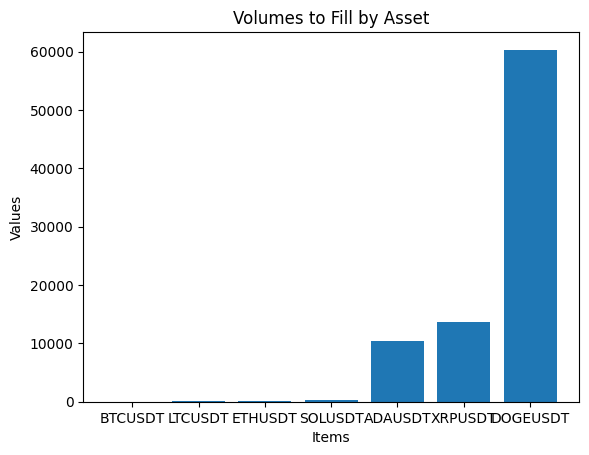

In [25]:
plot_volumes_to_fill()

## Cap at Volume Cap

In [26]:
positions_volcap = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
    .sort_values(["anonymized_id", "time_in_hour"])
    .reset_index(drop=True)
)

positions_volcap["position"] = 0.0

# cap_col = "volume"
cap_col = f"{side}_vol_1" 
percentile = 20 # TODO: vary percentile

for anon_id in ids:

    volume_cap = np.percentile(X_df[X_df["anonymized_id"] == anon_id][cap_col], percentile) 
    if volume_cap == 0:
        print("mean used!!!")
        volume_cap = np.mean(X_df[X_df["anonymized_id"] == anon_id][cap_col])

    weights = np.linspace(0, 1, 60) ** 5
    weights /= weights.sum()

    if not np.isclose(weights.sum(), 1):
        print(f"{anon_id} doesn't have weights that sum to 1.")

    positions = weights * volume_to_fill

    # simply cap
    positions = np.minimum(weights * volume_to_fill, volume_cap)

    # assign to correct rows
    mask = positions_volcap["anonymized_id"] == anon_id
    positions_volcap.loc[mask, "position"] = weights * volume_to_fill

# --- sanity check ---
positions_volcap.head()

,anonymized_id,time_in_hour,position
0,10076153343292355,0 days 00:59:00,0.000000e+00
1,10076153343292355,0 days 00:59:01,5.410816e-10
2,10076153343292355,0 days 00:59:02,1.731461e-08
3,10076153343292355,0 days 00:59:03,1.314828e-07
4,10076153343292355,0 days 00:59:04,5.540676e-07


In [27]:
bps_volcap = []

for anon_id in ids:
    df_inst = y_df[y_df["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]

    id_positions = positions_volcap[positions_volcap["anonymized_id"] == anon_id].sort_values("time_in_hour")["position"].to_numpy()
    
    # Simulate
    model_vol, model_avg_price = simulate_walk_the_book(
        id_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        bps_volcap.append(impl_error * vol_penalty)

bps_volcap = np.array(bps_volcap)

print(f"\n{'='*50}")
print(f"MODEL IMPLEMENTATION ERROR traded volume capped")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(bps_volcap)}")
print(data_asset)

print(f"optimal_k: {df_k[df_k['Asset'] == data_asset]['bps_optimal_K'].iloc[0]} bps")

print(f"Mean:   {bps_volcap.mean():.4f} bps")
print(f"Median: {np.median(bps_volcap):.4f} bps")
print(f"Std:    {bps_volcap.std():.4f} bps")
print(f"Min:    {bps_volcap.min():.4f} bps")
print(f"Max:    {bps_volcap.max():.4f} bps")


MODEL IMPLEMENTATION ERROR traded volume capped
Instruments evaluated: 705
BTCUSDT
optimal_k: 1.323212 bps
Mean:   1.1666 bps
Median: 1.0755 bps
Std:    0.8034 bps
Min:    0.0028 bps
Max:    8.4762 bps


In [28]:
# TODO: why does capping not change with the percentile?

## Redistribute if Cap Exceeded

In [29]:
def capped_allocation(weights, total_volume, cap):
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()

    allocation = weights * total_volume
    capped = np.minimum(allocation, cap)

    deficit = total_volume - capped.sum()

    while deficit > 1e-9:
        free = capped < cap
        if not np.any(free):
            break

        w_free = weights[free]
        w_free = w_free / w_free.sum()

        increment = np.zeros_like(capped)
        increment[free] = w_free * deficit

        new_vals = np.minimum(capped + increment, cap)
        delta = new_vals - capped

        capped = new_vals
        deficit -= delta.sum()

    return capped


def process_group(group):
    anon_id = group.name

    cap_series = X_df.loc[X_df["anonymized_id"] == anon_id, cap_col]
    volume_cap = np.percentile(cap_series, percentile)

    n = len(group)
    weights = np.linspace(1, n, n)
    weights /= weights.sum()

    positions = capped_allocation(
        weights,
        volume_to_fill,
        volume_cap
    )

    return pd.DataFrame({
        "anonymized_id": np.full(n, anon_id, dtype="uint64"),
        "time_in_hour": group["time_in_hour"].values,
        "position": positions
    })


positions_volcap_dist = (
    ids.rename("anonymized_id").to_frame()
    .merge(future_times.rename("time_in_hour").to_frame(), how="cross")
    .sort_values(["anonymized_id", "time_in_hour"])
    .reset_index(drop=True)
)

# --- apply per id ---
positions_volcap_dist = (
    positions_volcap_dist
    .groupby("anonymized_id", group_keys=False)
    .apply(process_group)
    .reset_index(drop=True)
)

In [30]:
bps_volcap_dist = []

for anon_id in ids:
    df_inst = y_df[y_df["anonymized_id"] == anon_id].sort_values("time_in_hour")
    
    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]

    id_positions = positions_volcap_dist[positions_volcap_dist["anonymized_id"] == anon_id].sort_values("time_in_hour")["position"].to_numpy()
    
    # Simulate
    model_vol, model_avg_price = simulate_walk_the_book(
        id_positions, ask_prices, ask_vols, bid_prices, bid_vols
    )
    
    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        bps_volcap_dist.append(impl_error * vol_penalty)

bps_volcap_dist = np.array(bps_volcap_dist)

print(f"\n{'='*50}")
print(f"MODEL IMPLEMENTATION ERROR traded volume capped")
print(f"{'='*50}")
print(f"Instruments evaluated: {len(bps_volcap_dist)}")
print(data_asset)

print(f"optimal_k: {df_k[df_k['Asset'] == data_asset]['bps_optimal_K'].iloc[0]} bps")

print(f"Mean:   {bps_volcap_dist.mean():.4f} bps")
print(f"Median: {np.median(bps_volcap_dist):.4f} bps")
print(f"Std:    {bps_volcap_dist.std():.4f} bps")
print(f"Min:    {bps_volcap_dist.min():.4f} bps")
print(f"Max:    {bps_volcap_dist.max():.4f} bps")


MODEL IMPLEMENTATION ERROR traded volume capped
Instruments evaluated: 705
BTCUSDT
optimal_k: 1.323212 bps
Mean:   1.3489 bps
Median: 1.0819 bps
Std:    1.2033 bps
Min:    0.0011 bps
Max:    10.7944 bps


| Asset    | bps_optimal_K | capped | redistributed | percentile | capcol | weighting |
|----------|----------|----------|----------|----------|----------|----------|
| LTCUSDT | **4.819771** | 5.3623 | *5.3568* | 50 | vol_1 | linear |
| LTCUSDT | **4.819771** | 5.2787 | | 20 | | **5 |
| SOLUSDT | 5.343504| **5.2721** | | 20 | | **5 |
| ADAUSDT | **4.628115**| 5.5719 | | 20 | | **5 |
| XRPUSDT | 3.567023| **3.5624** | | 20 | | **5 |
| BTCUSDT | 1.323212| **1.1666** | | 20 | | **5 |
| DOGEUSDT | **4.976437** | *5.0408* | 5.0601 | 50 | vol_1 | linear |
| DOGEUSDT | **4.976437** | *5.0408* | 5.2257 | 25 | vol_1 | linear |
| DOGEUSDT | **4.976437** | *5.0408* | 5.0453 | 75 | vol_1 | linear |
| DOGEUSDT | **4.976437** | *5.0408* | 6.1308 | 10 | vol_1 | linear |
| DOGEUSDT | *4.976437* | **4.9037** | | 20 | | **3 |
| SOLUSDT | **5.343504** | *5.3986* | 5.4029 | 50 | vol_1 | linear |
| ADAUSDT | **4.628115** | *5.7528* | 5.7582 | 50 | vol_1 | linear |
| ETHUSDT | *2.712073* | **2.6590** | 2.7480 | 50 | vol_1 | linear |
| ETHUSDT | *2.712073* | **2.6590** | 3.8072 | 20 | vol_1 | linear |
| ETHUSDT | *2.712073* | **2.5705** | | | | **2 |
| ETHUSDT | *2.712073* | **2.5508** | | | | **3 |
| ETHUSDT | *2.712073* | **2.5749** | | | | **4 |
| ETHUSDT | **2.712073** | *2.9971* | |20 | | **10 |


# TODO: Compare Volatility across assets. Is LTC generally more/less Volatile than other Assets? Because it's the only asset with low volume to fill that where uniform vs k doesn't improve... 